## What makes a beauty product successful?

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

## Read & Inspect Data

In [3]:
info = pd.read_csv('../data/archive/product_info.csv', na_values = '')
info.head(2)

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0


In [4]:
info.describe()

,brand_id,loves_count,rating,reviews,price_usd,value_price_usd,sale_price_usd,limited_edition,new,online_only,out_of_stock,sephora_exclusive,child_count,child_max_price,child_min_price
count,8494.000000,8.494000e+03,8216.000000,8216.000000,8494.000000,451.000000,270.000000,8494.000000,8494.000000,8494.000000,8494.000000,8494.000000,8494.000000,2754.000000,2754.000000
mean,5422.440546,2.917957e+04,4.194513,448.545521,51.655595,91.168537,20.207889,0.070285,0.071698,0.219096,0.073699,0.279374,1.631622,53.792023,39.665802
std,1709.595957,6.609212e+04,0.516694,1101.982529,53.669234,79.195631,24.327352,0.255642,0.258002,0.413658,0.261296,0.448718,5.379470,58.765894,38.685720
min,1063.000000,0.000000e+00,1.000000,1.000000,3.000000,0.000000,1.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,3.000000
25%,5333.000000,3.758000e+03,3.981725,26.000000,25.000000,45.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22.000000,19.000000
50%,6157.500000,9.880000e+03,4.289350,122.000000,35.000000,67.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,32.000000,28.000000
75%,6328.000000,2.684125e+04,4.530525,418.000000,58.000000,108.500000,25.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,59.000000,42.000000
max,8020.000000,1.401068e+06,5.000000,21281.000000,1900.000000,617.000000,320.000000,1.000000,1.000000,1.000000,1.000000,1.000000,105.000000,570.000000,400.000000


In [5]:
info.info()

<class 'pandas.DataFrame'>
RangeIndex: 8494 entries, 0 to 8493
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_id          8494 non-null   str    
 1   product_name        8494 non-null   str    
 2   brand_id            8494 non-null   int64  
 3   brand_name          8494 non-null   str    
 4   loves_count         8494 non-null   int64  
 5   rating              8216 non-null   float64
 6   reviews             8216 non-null   float64
 7   size                6863 non-null   str    
 8   variation_type      7050 non-null   str    
 9   variation_value     6896 non-null   str    
 10  variation_desc      1250 non-null   str    
 11  ingredients         7549 non-null   str    
 12  price_usd           8494 non-null   float64
 13  value_price_usd     451 non-null    float64
 14  sale_price_usd      270 non-null    float64
 15  limited_edition     8494 non-null   int64  
 16  new              

In [6]:
# read the reviews and join
r1 = pd.read_csv('../data/archive/reviews_0-250.csv', na_values = '')
r2 = pd.read_csv('../data/archive/reviews_250-500.csv', na_values = '')
r3 = pd.read_csv('../data/archive/reviews_500-750.csv', na_values = '')
r4 = pd.read_csv('../data/archive/reviews_750-1250.csv', na_values = '')
r5 = pd.read_csv('../data/archive/reviews_1250-end.csv', na_values = '')
reviews = pd.concat([r1, r2, r3, r4, r5], axis = 0)
reviews.head(2)

/var/folders/x6/m_7lfd010dbdw23y_wb5glnw0000gn/T/ipykernel_72390/782996434.py:2: DtypeWarning: Columns (0: author_id) have mixed types. Specify dtype option on import or set low_memory=False.
  r1 = pd.read_csv('../data/archive/reviews_0-250.csv', na_values = '')
/var/folders/x6/m_7lfd010dbdw23y_wb5glnw0000gn/T/ipykernel_72390/782996434.py:5: DtypeWarning: Columns (0: author_id) have mixed types. Specify dtype option on import or set low_memory=False.
  r4 = pd.read_csv('../data/archive/reviews_750-1250.csv', na_values = '')
/var/folders/x6/m_7lfd010dbdw23y_wb5glnw0000gn/T/ipykernel_72390/782996434.py:6: DtypeWarning: Columns (0: author_id) have mixed types. Specify dtype option on import or set low_memory=False.
  r5 = pd.read_csv('../data/archive/reviews_1250-end.csv', na_values = '')


,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0
1,1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0


In [7]:
reviews.describe()

,Unnamed: 0,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,price_usd
count,1.094411e+06,1.094411e+06,926423.000000,532819.000000,1.094411e+06,1.094411e+06,1.094411e+06,1.094411e+06
mean,1.989864e+05,4.299158e+00,0.839962,0.767782,4.177126e+00,8.948695e-01,3.282257e+00,4.900838e+01
std,1.749886e+05,1.149444e+00,0.366642,0.317164,2.271524e+01,5.288943e+00,1.967482e+01,4.004338e+01
min,0.000000e+00,1.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00
25%,5.590600e+04,4.000000e+00,1.000000,0.652174,0.000000e+00,0.000000e+00,0.000000e+00,2.500000e+01
50%,1.308240e+05,5.000000e+00,1.000000,0.928571,0.000000e+00,0.000000e+00,0.000000e+00,3.900000e+01
75%,3.285265e+05,5.000000e+00,1.000000,1.000000,3.000000e+00,1.000000e+00,3.000000e+00,6.200000e+01
max,6.021290e+05,5.000000e+00,1.000000,1.000000,5.464000e+03,1.159000e+03,5.050000e+03,1.900000e+03


In [8]:
reviews.info()

<class 'pandas.DataFrame'>
Index: 1094411 entries, 0 to 49976
Data columns (total 19 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   Unnamed: 0                1094411 non-null  int64  
 1   author_id                 1094411 non-null  object 
 2   rating                    1094411 non-null  int64  
 3   is_recommended            926423 non-null   float64
 4   helpfulness               532819 non-null   float64
 5   total_feedback_count      1094411 non-null  int64  
 6   total_neg_feedback_count  1094411 non-null  int64  
 7   total_pos_feedback_count  1094411 non-null  int64  
 8   submission_time           1094411 non-null  str    
 9   review_text               1092967 non-null  str    
 10  review_title              783757 non-null   str    
 11  skin_tone                 923872 non-null   str    
 12  eye_color                 884783 non-null   str    
 13  skin_type                 982854 non-null   s

## Data Cleaning & Manipulation

In [9]:
# left join reviews --> info (each row is a review)
df = reviews.merge(info, how = 'left', on = 'product_id', suffixes = ['_review','_product'])

# drop irrelevant columns
df = df.drop(columns = ['Unnamed: 0','submission_time','ingredients','child_count','child_max_price','child_min_price',
                        'review_text','review_title','tertiary_category','rating_product','product_name_review', 
                        'brand_name_review', 'price_usd_review', 'brand_id', 'size',
                        'variation_type', 'variation_value', 'variation_desc','author_id','value_price_usd',
                        'sale_price_usd','out_of_stock','online_only','highlights'])
df = df.rename(columns = {'rating_review':'rating','helpfulness':'proportion of positive feedback',
                          'product_name_product':'product name', 'brand_name_product':'brand name',
                          'price_usd_product':'price'})
df.head(3)

,rating,is_recommended,proportion of positive feedback,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,skin_tone,eye_color,skin_type,hair_color,...,product name,brand name,loves_count,reviews,price,limited_edition,new,sephora_exclusive,primary_category,secondary_category
0,5,1.0,1.0,2,0,2,NaN,brown,dry,black,...,Gentle Hydra-Gel Face Cleanser,NUDESTIX,177,1.0,19.0,0,0,0,Skincare,Cleansers
1,1,0.0,NaN,0,0,0,NaN,NaN,NaN,NaN,...,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,1081315,16118.0,24.0,0,0,1,Skincare,Lip Balms & Treatments
2,5,1.0,NaN,0,0,0,light,brown,dry,blonde,...,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,1081315,16118.0,24.0,0,0,1,Skincare,Lip Balms & Treatments


In [10]:
# handling missing values
df['proportion of positive feedback'] = df['proportion of positive feedback'].fillna(0)
df['is_recommended'] = df['is_recommended'].fillna('Unknown')
df['skin_tone'] = df['skin_tone'].fillna('Unknown')
df['eye_color'] = df['eye_color'].fillna('Unknown')
df['skin_type'] = df['skin_type'].fillna('Unknown')
df['hair_color'] = df['hair_color'].fillna('Unknown')
df.head(3)

,rating,is_recommended,proportion of positive feedback,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,skin_tone,eye_color,skin_type,hair_color,...,product name,brand name,loves_count,reviews,price,limited_edition,new,sephora_exclusive,primary_category,secondary_category
0,5,1.0,1.0,2,0,2,Unknown,brown,dry,black,...,Gentle Hydra-Gel Face Cleanser,NUDESTIX,177,1.0,19.0,0,0,0,Skincare,Cleansers
1,1,0.0,0.0,0,0,0,Unknown,Unknown,Unknown,Unknown,...,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,1081315,16118.0,24.0,0,0,1,Skincare,Lip Balms & Treatments
2,5,1.0,0.0,0,0,0,light,brown,dry,blonde,...,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,1081315,16118.0,24.0,0,0,1,Skincare,Lip Balms & Treatments


In [11]:
df.isna().sum()

rating                             0
is_recommended                     0
proportion of positive feedback    0
total_feedback_count               0
total_neg_feedback_count           0
total_pos_feedback_count           0
skin_tone                          0
eye_color                          0
skin_type                          0
hair_color                         0
product_id                         0
product name                       0
brand name                         0
loves_count                        0
reviews                            0
price                              0
limited_edition                    0
new                                0
sephora_exclusive                  0
primary_category                   0
secondary_category                 0
dtype: int64

In [12]:
len(df)

1094411

## EDA

top brands

In [13]:
top_brands = df[['brand name','rating']].copy()
top_brands = top_brands.groupby('brand name')['rating'].agg('mean').reset_index().sort_values(by = 'rating', ascending = False)
top_brands.head(5)

,brand name,rating
29,Erno Laszlo,5.000000
41,Gisou,4.901235
73,MARA,4.861229
72,MACRENE actives,4.779817
16,DAMDAM,4.739362


top product categories

In [14]:
top_products = df[['primary_category','secondary_category','rating']].copy()
top_products = top_products.groupby(['primary_category','secondary_category'])['rating'].agg('mean').reset_index().sort_values(by = 'rating', ascending = False)
top_products.head(5)

,primary_category,secondary_category,rating
0,Skincare,Cleansers,4.344181
4,Skincare,Masks,4.341127
3,Skincare,Lip Balms & Treatments,4.334457
6,Skincare,Moisturizers,4.317348
10,Skincare,Treatments,4.304316


rating distribution by product category

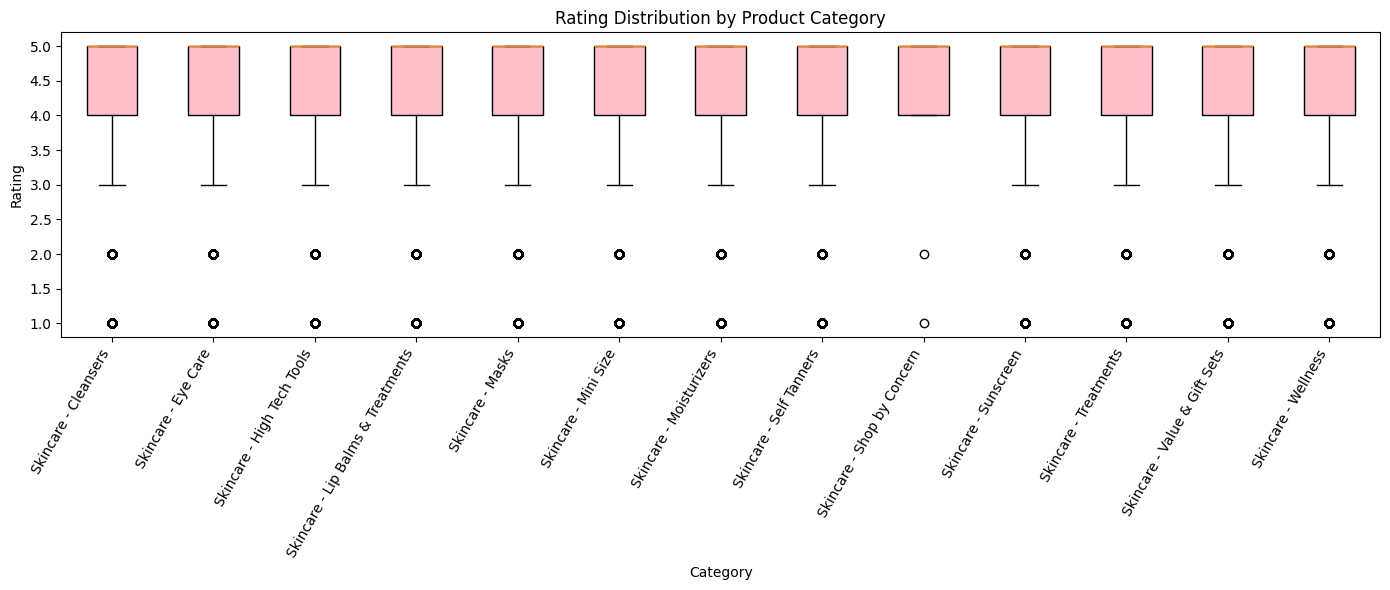

In [15]:
distr_bycat = df[['primary_category','secondary_category','rating']].copy()
distr_bycat['category_label'] = distr_bycat['primary_category'] + ' - ' + distr_bycat['secondary_category']

grouped = distr_bycat.groupby('category_label')['rating'].apply(list)

plt.figure(figsize=(14, 6))

box = plt.boxplot(grouped.values, tick_labels=grouped.index, vert=True, patch_artist=True)

for patch in box['boxes']:
    patch.set_facecolor('pink')

plt.title('Rating Distribution by Product Category')
plt.xlabel('Category')
plt.ylabel('Rating')
plt.xticks(rotation=60, ha='right')

plt.tight_layout()
plt.show()


relationship between price and rating

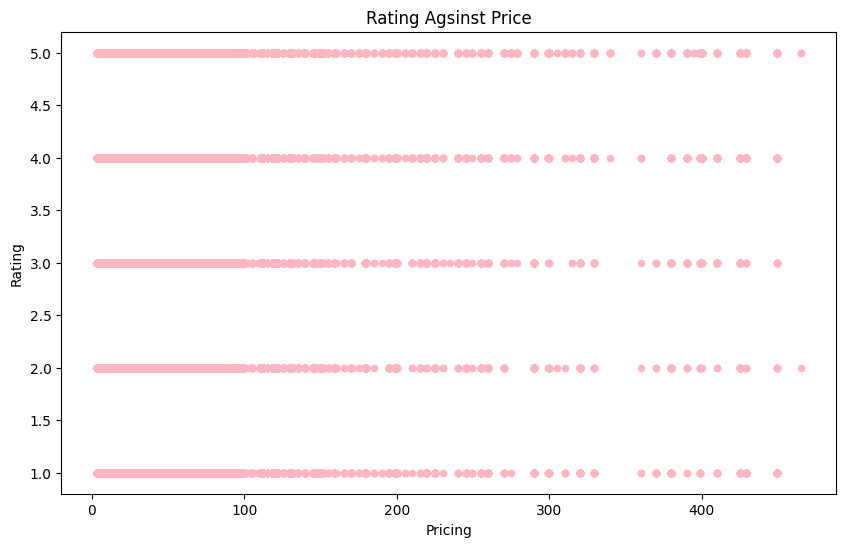

In [16]:
price_and_rating = df[['price','rating']].copy()
price_and_rating_filtered = price_and_rating[price_and_rating['price']<500]
price_and_rating_filtered.plot(kind = 'scatter', x = 'price', y = 'rating',
                      xlabel = 'Pricing', ylabel = 'Rating', figsize = (10,6), color = 'lightpink', 
                      title = 'Rating Agsinst Price', legend = False)
plt.show()


price segmentation analysis (do high end products perform better?)

- Budget (< $20)
- Mid-range ($20–50)
- Premium ($50+)

Boxplot: price tier vs rating

In [17]:
price_and_rating['price_tier'] = pd.cut(
    price_and_rating['price'],
    bins=[0, 20, 50, np.inf],
    labels=['Budget (<$20)', 'Mid-range ($20-50)', 'Premium ($50+)']
)

price_and_rating.head(3)

,price,rating,price_tier
0,19.0,5,Budget (<$20)
1,24.0,1,Mid-range ($20-50)
2,24.0,5,Mid-range ($20-50)


In [18]:
price_and_rating['price_tier'].value_counts()

price_tier
Mid-range ($20-50)    514727
Premium ($50+)        379496
Budget (<$20)         200188
Name: count, dtype: int64

/var/folders/x6/m_7lfd010dbdw23y_wb5glnw0000gn/T/ipykernel_72390/977015968.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


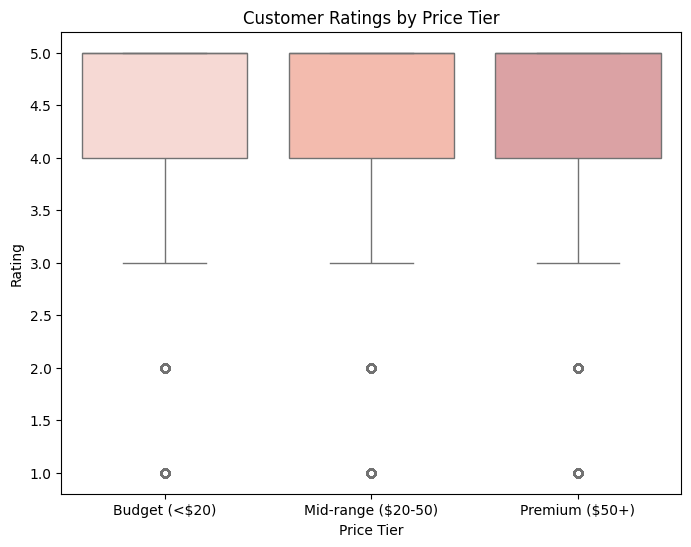

In [19]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=price_and_rating,
    x='price_tier',
    y='rating',
    palette = ['#FCD5CE', '#FFB4A2', '#E5989B']
)

plt.title("Customer Ratings by Price Tier")
plt.xlabel("Price Tier")
plt.ylabel("Rating")
plt.show()

top products by rating and reviews

In [20]:
ratings_and_reviews = df[['rating','reviews','brand name','primary_category','secondary_category']].copy()
ratings_and_reviews = ratings_and_reviews.groupby(['brand name','primary_category','secondary_category'])[['rating','reviews']].agg('mean').reset_index().sort_values(by = ['rating','reviews'], ascending = False)
ratings_and_reviews.reset_index(drop = True).head(5)

,brand name,primary_category,secondary_category,rating,reviews
0,The Nue Co.,Skincare,Treatments,5.0,12.0
1,The Nue Co.,Skincare,Moisturizers,5.0,7.0
2,The Nue Co.,Skincare,Cleansers,5.0,6.0
3,ROSE INC,Skincare,Value & Gift Sets,5.0,4.0
4,Flora + Bast,Skincare,Moisturizers,5.0,3.0


relationship between helpfulness, total feedback and rating

-- do higher ratings receive more helpful votes
-- do negative reviews affect rating

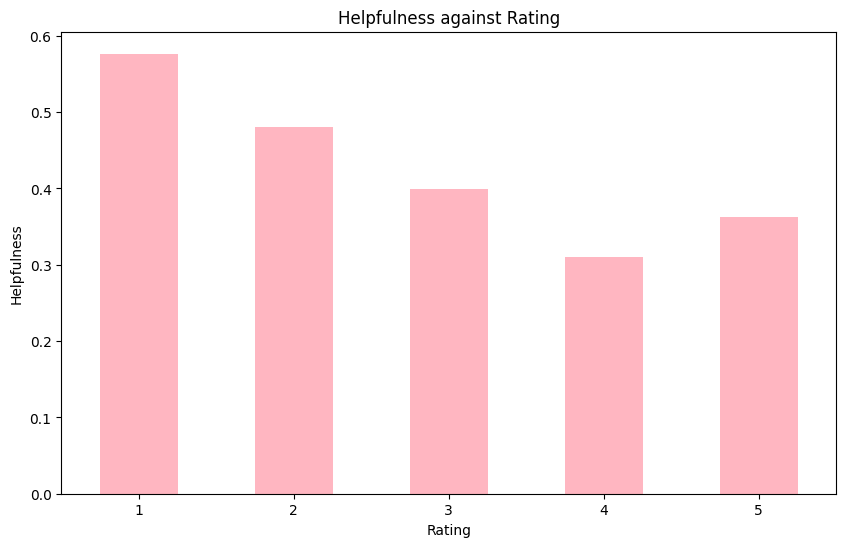

In [21]:
helpful_feedback = df[['proportion of positive feedback','total_feedback_count','total_neg_feedback_count','total_pos_feedback_count','rating']].copy()
helpful_rating = helpful_feedback.groupby('rating')['proportion of positive feedback'].mean()
helpful_rating.plot(kind = 'bar', x = 'rating', y = 'proportion of positive feedback',
                      xlabel = 'Rating', ylabel = 'Helpfulness', figsize = (10,6), color = 'lightpink', 
                      title = 'Helpfulness against Rating', legend = False, rot = 0)
plt.show()

In [22]:
helpful_feedback.head(3)

,proportion of positive feedback,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,rating
0,1.0,2,0,2,5
1,0.0,0,0,0,1
2,0.0,0,0,0,5


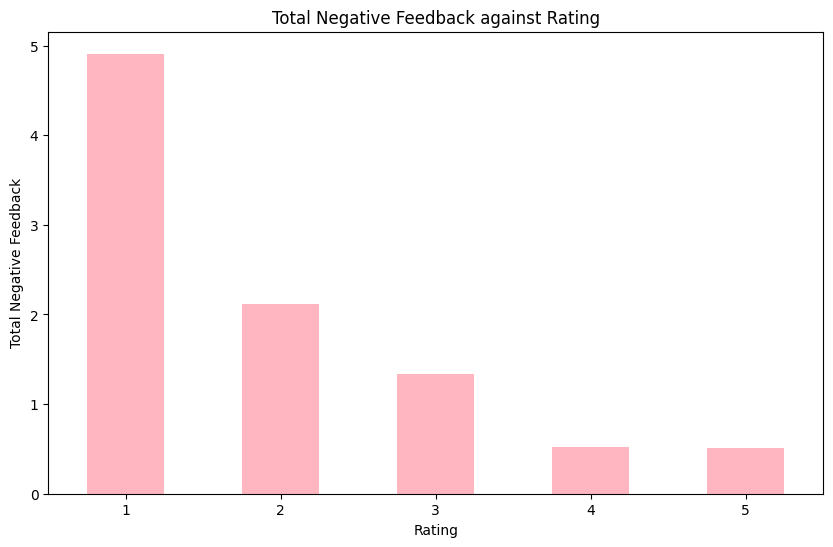

In [23]:
neg_feedback = helpful_feedback.copy()
neg_feedback = neg_feedback.groupby('rating')['total_neg_feedback_count'].mean()
neg_feedback.plot(kind = 'bar', x = 'total_neg_feedback_count', y = 'rating', 
                  xlabel = 'Rating', ylabel = 'Total Negative Feedback', title = 'Total Negative Feedback against Rating',
                  color = 'lightpink', rot = 0, figsize = (10,6))
plt.show()

skin type vs rating

In [24]:
skintype = df[['brand name','secondary_category','skin_type','rating','skin_tone']].copy()
vs_rating = skintype.groupby(['skin_type'])['rating'].agg('mean').reset_index().sort_values(by = 'rating', ascending = False)
vs_rating.reset_index(drop = True).head(6)


,skin_type,rating
0,Unknown,4.313122
1,combination,4.309339
2,dry,4.291249
3,normal,4.282276
4,oily,4.270910


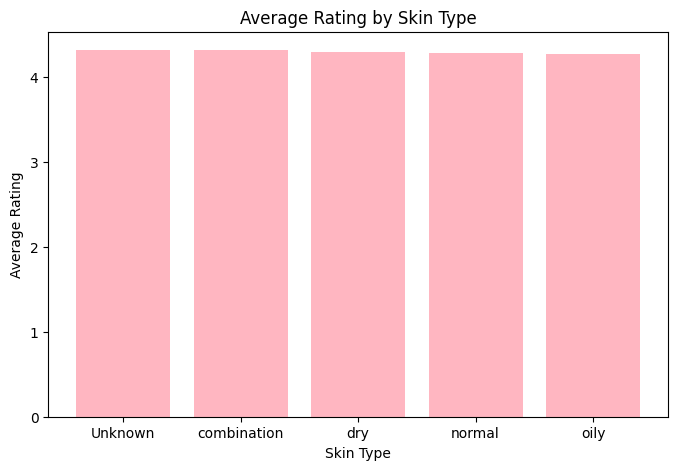

In [25]:
plt.figure(figsize=(8,5))
plt.bar(vs_rating['skin_type'], vs_rating['rating'], color = 'lightpink')

plt.title('Average Rating by Skin Type')
plt.xlabel('Skin Type')
plt.ylabel('Average Rating')

plt.show()

In [26]:
vs_rating = skintype.groupby(['skin_tone'])['rating'].agg('mean').reset_index().sort_values(by = 'rating', ascending = False)
vs_rating.reset_index(drop = True).head(6)

,skin_tone,rating
0,medium,4.331186
1,Unknown,4.321240
2,lightMedium,4.318829
3,rich,4.307482
4,light,4.301417
5,tan,4.284073


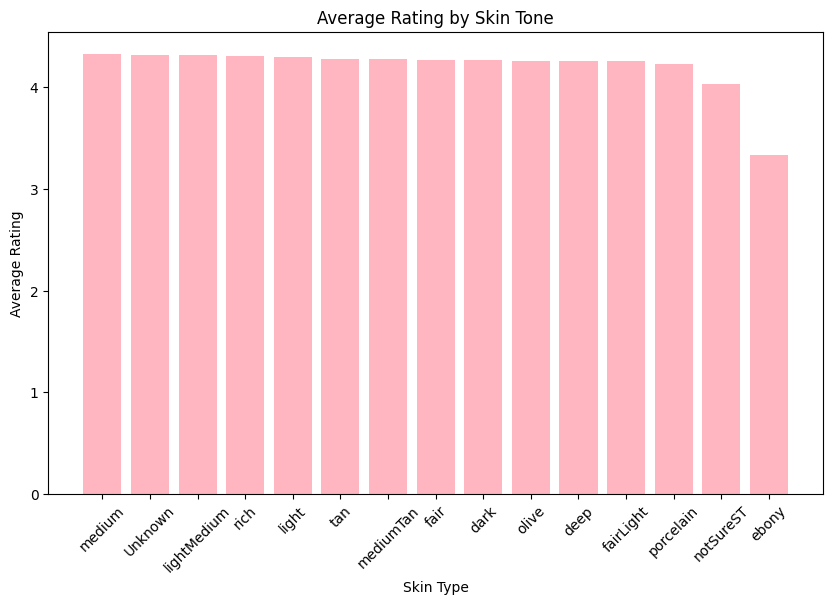

In [27]:
plt.figure(figsize=(10,6))
plt.bar(vs_rating['skin_tone'], vs_rating['rating'], color = 'lightpink')

plt.title('Average Rating by Skin Tone')
plt.xticks(rotation = 45)
plt.xlabel('Skin Type')
plt.ylabel('Average Rating')

plt.show()

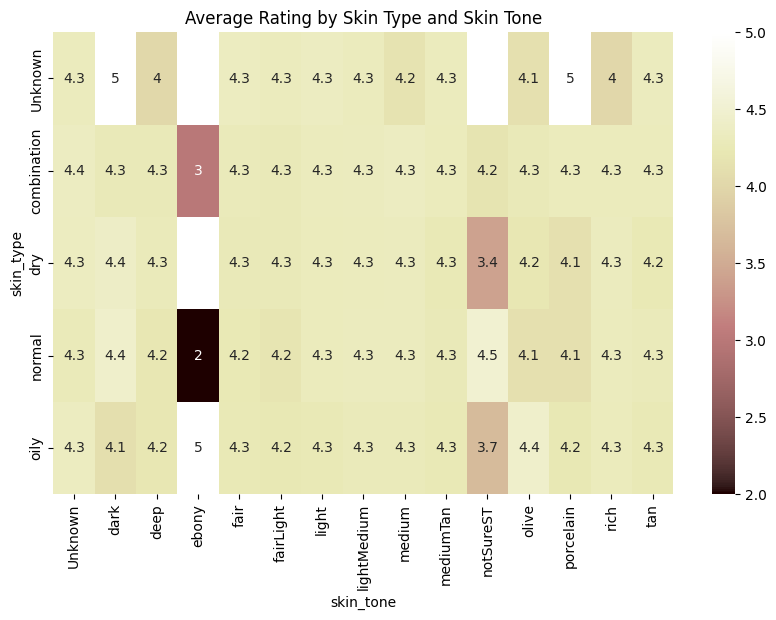

In [28]:
heat = df.pivot_table(
    values='rating',
    index='skin_type',
    columns='skin_tone',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))
sns.heatmap(heat, annot=True, cmap='pink')

plt.title('Average Rating by Skin Type and Skin Tone')
plt.show()

In [30]:
df.columns

Index(['rating', 'is_recommended', 'proportion of positive feedback',
       'total_feedback_count', 'total_neg_feedback_count',
       'total_pos_feedback_count', 'skin_tone', 'eye_color', 'skin_type',
       'hair_color', 'product_id', 'product name', 'brand name', 'loves_count',
       'reviews', 'price', 'limited_edition', 'new', 'sephora_exclusive',
       'primary_category', 'secondary_category'],
      dtype='str')

In [35]:
df['reviews'].nunique()

877